In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Load dataset
df = pd.read_csv("../data/heart.csv")
df = df.replace("?", np.nan)

for col in ["ca", "thal"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary target
y = (df["num"] > 0).astype(int)

# Use ONLY numeric features (fast)
X = df.drop(columns=["num"]).select_dtypes(exclude="object")

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Data ready:", X_train.shape, X_val.shape)


Data ready: (736, 8) (184, 8)


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=1.0, solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, baseline_model.predict(X_train))
val_acc = accuracy_score(y_val, baseline_model.predict(X_val))

print("Baseline Train Accuracy:", train_acc)
print("Baseline Validation Accuracy:", val_acc)


Baseline Train Accuracy: 0.7975543478260869
Baseline Validation Accuracy: 0.7880434782608695


c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features 

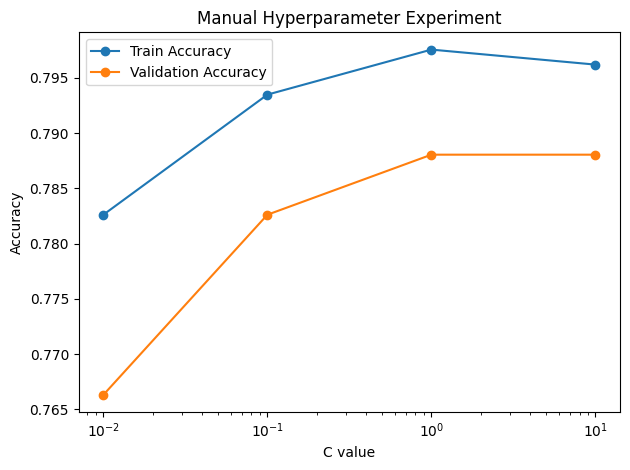

In [3]:
import matplotlib.pyplot as plt

C_values = [0.01, 0.1, 1, 10]
train_scores = []
val_scores = []

for c in C_values:
    baseline_model.set_params(logreg__C=c)
    baseline_model.fit(X_train, y_train)

    train_scores.append(accuracy_score(y_train, baseline_model.predict(X_train)))
    val_scores.append(accuracy_score(y_val, baseline_model.predict(X_val)))

# Plot
plt.plot(C_values, train_scores, marker="o", label="Train Accuracy")
plt.plot(C_values, val_scores, marker="o", label="Validation Accuracy")
plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.title("Manual Hyperparameter Experiment")
plt.legend()
plt.tight_layout()
plt.savefig("../plots/perf_vs_hyperparam.png")
plt.show()


In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "logreg__C": [0.1, 0.5, 1, 2]
}

grid = GridSearchCV(
    baseline_model,
    param_grid,
    cv=3,          # fast & allowed
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Mean Accuracy:", grid.best_score_)


c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features 

Best Parameters: {'logreg__C': 2}
Best CV Mean Accuracy: 0.7948177645041756


c:\Users\talek\Downloads\CreativeArc-Internship\week2-assessment\venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
